In [1]:
import pandas as pd
df = pd.read_stata("nsch_2024e_topical.dta")

In [2]:
import pandas as pd
file_dicts = [
    {
        'stata_file': '/content/nsch_2024e_topical.dta',
        'export_file': '/content/example_1.csv',
    },
]
for file in file_dicts:
    df = pd.read_stata(file['stata_file'])
    df.to_csv(file['export_file'], index=False)

In [3]:
df.head()

,height,fipsst,stratum,hhid,formtype,totkids_r,tenure,hhlanguage,sc_age_years,sc_sex,...,hhcount_if,higrade,higrade_tvis,fpl_i1,fpl_i2,fpl_i3,fpl_i4,fpl_i5,fpl_i6,fwc
0,NaN,48,1,24000016,T3,3,2,1.0,12,2,...,0,3,4,400,400,400,400,400,400,14108.624367
1,NaN,48,1,24000017,T1,1,2,1.0,5,2,...,0,3,4,400,400,400,400,400,400,7995.775609
2,NaN,47,1,24000044,T1,2,1,1.0,5,1,...,0,3,4,400,400,400,400,239,195,1593.130507
3,NaN,13,2A,24000054,T1,2,2,1.0,2,2,...,0,3,4,400,400,400,400,400,400,4395.677115
4,NaN,39,1,24000057,T1,2,1,1.0,2,2,...,0,3,4,400,400,400,400,400,400,1384.962653


In [4]:
df.shape

(51375, 457)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51375 entries, 0 to 51374
Columns: 457 entries, height to fwc
dtypes: float64(412), int16(7), int32(1), int8(35), object(2)
memory usage: 164.9+ MB


In [6]:
ndd_cols = ['k2q31a', 'k2q35a', 'k2q36a', 'k2q60a', 'k2q30a', 'k2q37a']
ndd_names = ['ADHD', 'Autism', 'Dev_Delay', 'Intellectual_Disability', 'Learning_Disability', 'Speech_Disorder']

for col, name in zip(ndd_cols, ndd_names):
    if col in df.columns:
        print(f"\n{name} ({col}):")
        print(df[col].value_counts())
    else:
        print(f"{name} ({col}): NOT FOUND")


ADHD (k2q31a):
k2q31a
2.0    44284
1.0     6714
Name: count, dtype: int64

Autism (k2q35a):
k2q35a
2.0    48777
1.0     2352
Name: count, dtype: int64

Dev_Delay (k2q36a):
k2q36a
2.0    47246
1.0     3894
Name: count, dtype: int64

Intellectual_Disability (k2q60a):
k2q60a
2.0    50467
1.0      697
Name: count, dtype: int64

Learning_Disability (k2q30a):
k2q30a
2.0    46996
1.0     4155
Name: count, dtype: int64

Speech_Disorder (k2q37a):
k2q37a
2.0    46462
1.0     4746
Name: count, dtype: int64


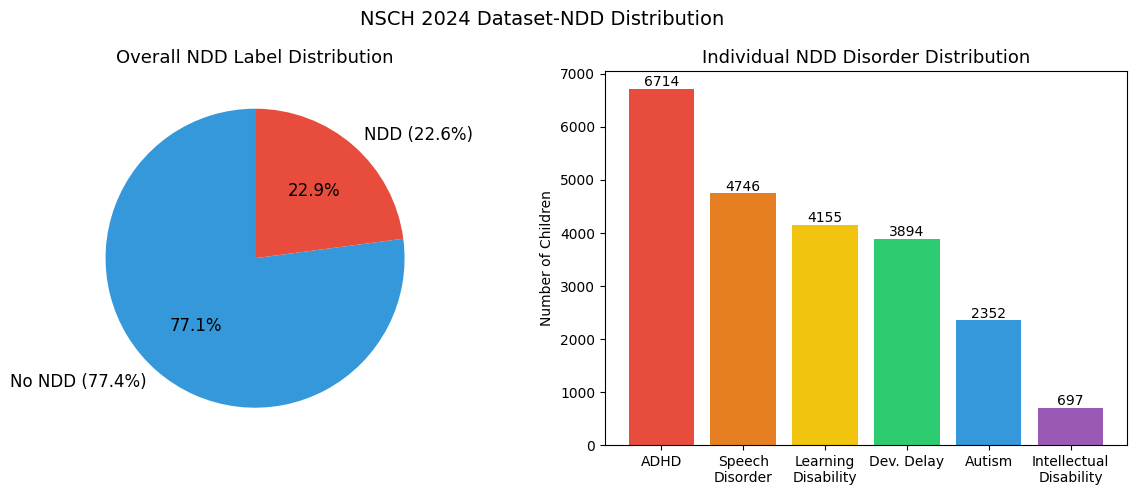

In [7]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

###eft-class distribution pie
labels = ['No NDD (77.4%)', 'NDD (22.6%)']
sizes = [39600, 11775]
colors = ['#3498db', '#e74c3c']
axes[0].pie(sizes, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Overall NDD Label Distribution', fontsize=13)

###right-individual disorder counts
disorders = ['ADHD', 'Speech\nDisorder', 'Learning\nDisability',
             'Dev. Delay', 'Autism', 'Intellectual\nDisability']
counts = [6714, 4746, 4155, 3894, 2352, 697]
colors2 = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6']
bars = axes[1].bar(disorders, counts, color=colors2)
axes[1].set_title('Individual NDD Disorder Distribution', fontsize=13)
axes[1].set_ylabel('Number of Children')
for bar, val in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 str(val), ha='center', fontsize=10)

plt.suptitle('NSCH 2024 Dataset-NDD Distribution', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
import numpy as np

In [9]:
###1.0 = Yes, 2.0 = No
def to_binary(series):
    return (series == 1.0).astype(int)

df['ADHD']      = to_binary(df['k2q31a'])
df['Autism']    = to_binary(df['k2q35a'])
df['Dev_Delay'] = to_binary(df['k2q36a'])
df['Intel_Dis'] = to_binary(df['k2q60a'])
df['Learn_Dis'] = to_binary(df['k2q30a'])
df['Speech']    = to_binary(df['k2q37a'])

###final target: 1 if child has ANY NDD, 0 if not
df['NDD_label'] = ((df['ADHD'] + df['Autism'] + df['Dev_Delay'] +
                    df['Intel_Dis'] + df['Learn_Dis'] + df['Speech']) > 0).astype(int)

print("NDD label distribution:")
print(df['NDD_label'].value_counts())
print(f"\nPositive rate: {df['NDD_label'].mean()*100:.1f}%")

NDD label distribution:
NDD_label
0    39600
1    11775
Name: count, dtype: int64

Positive rate: 22.9%


/tmp/ipykernel_9650/643498588.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['ADHD']      = to_binary(df['k2q31a'])
/tmp/ipykernel_9650/643498588.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Autism']    = to_binary(df['k2q35a'])
/tmp/ipykernel_9650/643498588.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use

In [10]:
###DATA LEAKAGE PREVENTION
ndd_source_cols = ['k2q31a','k2q31b','k2q31c','k2q31d',
                   'k2q35a','k2q35b','k2q35c','k2q35d',
                   'k2q36a','k2q36b','k2q36c',
                   'k2q60a','k2q60b','k2q60c',
                   'k2q30a','k2q30b','k2q30c',
                   'k2q37a','k2q37b','k2q37c',
                   'ADHD','Autism','Dev_Delay',
                   'Intel_Dis','Learn_Dis','Speech',
                   'addtreat','autismtreat','autismmed']

df_clean = df.drop(columns=[c for c in ndd_source_cols if c in df.columns])
print("Shape after dropping NDD source cols:", df_clean.shape)

Shape after dropping NDD source cols: (51375, 435)


In [11]:
###keeping only numeric columns
X = df_clean.drop(columns=['NDD_label']).select_dtypes(include=[np.number])
y = df_clean['NDD_label']

###filling missing values with median
X = X.fillna(X.median())

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

Features shape: (51375, 432)
Target shape: (51375,)

Class distribution:
NDD_label
0    39600
1    11775
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts())

Train size: (41100, 432)
Test size: (10275, 432)

Train class distribution:
NDD_label
0    31680
1     9420
Name: count, dtype: int64


In [13]:
!pip install scikit-learn -q

from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
###removing features that barely change across samples
selector_var = VarianceThreshold(threshold=0.01)
X_train_var = selector_var.fit_transform(X_train)
X_test_var = selector_var.transform(X_test)

cols_after_var = X_train.columns[selector_var.get_support()]
print(f"Features before: {X_train.shape[1]}")
print(f"Features after variance threshold: {X_train_var.shape[1]}")

Features before: 432
Features after variance threshold: 371


In [15]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

###Chi2 needs non-negative values — scale to 0-1 first
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_var)
X_test_scaled = scaler.transform(X_test_var)

###select top 80 features by chi2 score
selector_chi2 = SelectKBest(chi2, k=80)
X_train_chi2 = selector_chi2.fit_transform(X_train_scaled, y_train)
X_test_chi2 = selector_chi2.transform(X_test_scaled)

cols_after_chi2 = cols_after_var[selector_chi2.get_support()]
print(f"Features after chi-square: {X_train_chi2.shape[1]}")
print("\nTop 20 features by chi2 score:")
import pandas as pd
chi2_scores = pd.Series(selector_chi2.scores_, index=cols_after_var)
print(chi2_scores.nlargest(20))

Features after chi-square: 80

Top 20 features by chi2 score:
sc_cshcn      3098.340389
makefriend    3047.132386
k7q04r_r      2899.101242
k4q38         2804.341413
hcability     2680.714604
k4q36         2467.856827
k6q15         2357.035163
sescurrsvc    2180.655538
totcshcn      2178.311994
k8q31         1925.902731
k7q83_r       1756.887529
sc_k2q13      1683.350824
k7q82_r       1601.868299
sc_k2q22      1584.065487
sc_k2q20      1313.951820
sc_k2q10      1265.459614
bullied_r     1205.903620
sc_k2q19      1056.779224
memorycond     979.771207
k7q30          944.521741
dtype: float64


In [16]:
#RF

from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_chi2, y_train)

importances = pd.Series(rf_selector.feature_importances_, index=cols_after_chi2)
importances_sorted = importances.sort_values(ascending=False)

top_40_cols = importances_sorted.head(40).index.tolist()

print("Top 40 features by Random Forest importance:")
print(importances_sorted.head(40))

Top 40 features by Random Forest importance:
k4q36          0.106372
k6q15          0.098023
memorycond     0.044178
sc_cshcn       0.043031
k4q23          0.038681
sc_k2q22       0.037793
sc_k2q19       0.037588
totcshcn       0.033912
k2q34a         0.027279
birth_yr       0.024215
sc_k2q13       0.020546
hcability      0.019900
totnonshcn     0.016601
k11q43r        0.015577
k7q84_r        0.014970
grades         0.014686
k8q31          0.014477
screentime     0.013681
k4q38          0.013177
sc_k2q10       0.012858
k7q02r_r       0.011948
k7q85_r        0.011912
k7q83_r        0.011300
k2q33a         0.011248
k4q22_r        0.010364
k6q71_r        0.009910
k8q32          0.009714
makefriend     0.009577
k8q34          0.009540
ace1           0.009496
k2q01          0.008823
bullied_r      0.008650
k5q31_r        0.008454
k7q33          0.008414
k7q82_r        0.008324
sc_sex         0.007605
a2_relation    0.007342
sc_k2q20       0.007302
k8q30          0.007034
sescurrsvc     0.00

In [17]:
import numpy as np

###final 40 feature selection
X_train_final = pd.DataFrame(X_train_chi2, columns=cols_after_chi2)[top_40_cols]
X_test_final = pd.DataFrame(X_test_chi2, columns=cols_after_chi2)[top_40_cols]

print(f"Final train shape: {X_train_final.shape}")
print(f"Final test shape: {X_test_final.shape}")
print("\nClass distribution before SMOTE:")
print(y_train.value_counts())

Final train shape: (41100, 40)
Final test shape: (10275, 40)

Class distribution before SMOTE:
NDD_label
0    31680
1     9420
Name: count, dtype: int64


In [18]:
###SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train)

print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())
print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_smote).value_counts())
print(f"\nTraining samples before: {X_train_final.shape[0]}")
print(f"Training samples after:  {X_train_smote.shape[0]}")

Class distribution BEFORE SMOTE:
NDD_label
0    31680
1     9420
Name: count, dtype: int64

Class distribution AFTER SMOTE:
NDD_label
0    31680
1    31680
Name: count, dtype: int64

Training samples before: 41100
Training samples after:  63360


In [19]:
#LR

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)
y_pred_lr = lr_model.predict(X_test_final)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr)*100, "%")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 88.83698296836982 %
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      7920
           1       0.72      0.84      0.78      2355

    accuracy                           0.89     10275
   macro avg       0.83      0.87      0.85     10275
weighted avg       0.90      0.89      0.89     10275



In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)
y_pred_rf = rf_model.predict(X_test_final)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf)*100, "%")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 89.94647201946472 %
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      7920
           1       0.79      0.77      0.78      2355

    accuracy                           0.90     10275
   macro avg       0.86      0.85      0.86     10275
weighted avg       0.90      0.90      0.90     10275



In [21]:
#XGBOOST

from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_smote, y_train_smote)
y_pred_xgb = xgb_model.predict(X_test_final)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb)*100, "%")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 90.11192214111922 %
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      7920
           1       0.81      0.74      0.78      2355

    accuracy                           0.90     10275
   macro avg       0.87      0.85      0.86     10275
weighted avg       0.90      0.90      0.90     10275



In [22]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report

###linearSVC is much faster than SVC
svm_model = CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=1000))
svm_model.fit(X_train_smote, y_train_smote)
y_pred_svm = svm_model.predict(X_test_final)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm)*100, "%")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 88.8661800486618 %
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      7920
           1       0.72      0.84      0.78      2355

    accuracy                           0.89     10275
   macro avg       0.84      0.87      0.85     10275
weighted avg       0.90      0.89      0.89     10275



In [23]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
estimators = [
    ('lr', lr_model),
    ('rf', rf_model),
    ('xgb', xgb_model),
    ('svm', svm_model)
]
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

stacking_model.fit(X_train_smote, y_train_smote)
y_pred_stack = stacking_model.predict(X_test_final)

print("Stacking Model Accuracy:", accuracy_score(y_test, y_pred_stack)*100, "%")
print(classification_report(y_test, y_pred_stack))

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
import numpy as np

In [ ]:
###models and predictions
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM', 'Stacking']
y_preds = [y_pred_lr, y_pred_rf, y_pred_xgb, y_pred_svm, y_pred_stack]
models_list = [lr_model, rf_model, xgb_model, svm_model, stacking_model]

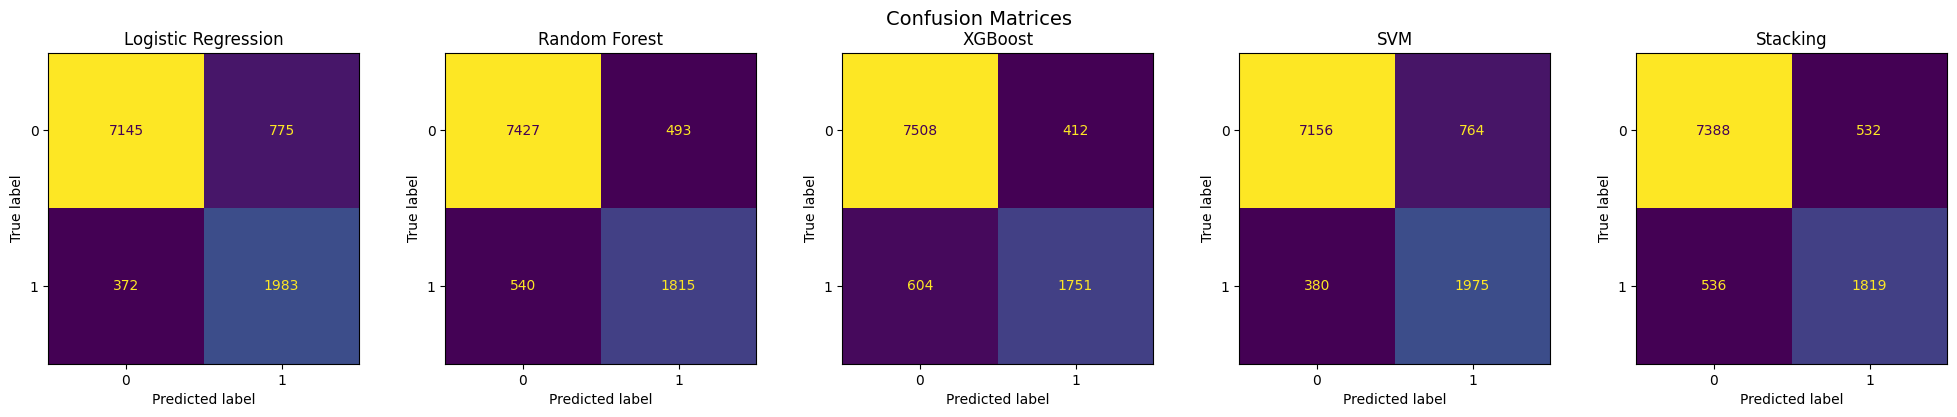

In [ ]:
###confusion matrices
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (name, y_pred) in enumerate(zip(model_names, y_preds)):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(name)
plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

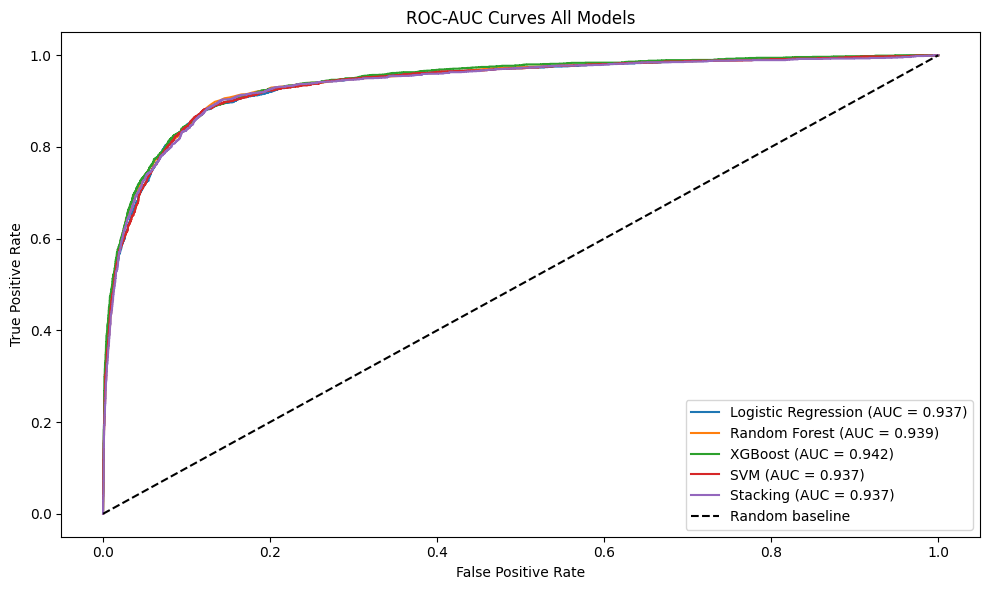

In [ ]:
###ROC-AUC curves
plt.figure(figsize=(10, 6))
for name, model in zip(model_names, models_list):
    y_prob = model.predict_proba(X_test_final)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curves All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
###SHAP
!pip install shap -q
import shap

In [ ]:
###SHAP on XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_final)

In [ ]:
###summary plot
shap.summary_plot(shap_values, X_test_final,
                  feature_names=top_40_cols,
                  show=True)

In [ ]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

disorders = {
    'ADHD': 'k2q31a',
    'Autism': 'k2q35a',
    'Dev_Delay': 'k2q36a'
}
disorder_results = {}

In [ ]:
###fixescale_pos_weight
for disorder_name, col in [('ADHD','k2q31a'), ('Autism','k2q35a'), ('Dev_Delay','k2q36a')]:
    print(f"\nTraining {disorder_name}...")

    y_disorder = (df[col] == 1.0).astype(int)
    y_dis_train = y_disorder.iloc[X_train_final.index]
    y_dis_test = y_disorder.iloc[X_test_final.index]

    neg = (y_dis_train == 0).sum()
    pos = (y_dis_train == 1).sum()
    ratio = neg / pos
    print(f"Class ratio: {ratio:.1f}")

    ###using scale_pos_weight instead of SMOTE
    xgb_dis = XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=ratio
    )
    xgb_dis.fit(X_train_final, y_dis_train)
    y_dis_pred = xgb_dis.predict(X_test_final)

    acc = accuracy_score(y_dis_test, y_dis_pred)
    disorder_results[disorder_name] = {'model': xgb_dis, 'accuracy': acc}
    print(f"{disorder_name} Accuracy: {acc*100:.2f}%")
    print(classification_report(y_dis_test, y_dis_pred))


Training ADHD...
Class ratio: 6.7
ADHD Accuracy: 63.73%
              precision    recall  f1-score   support

           0       0.87      0.69      0.77      8934
           1       0.13      0.30      0.18      1341

    accuracy                           0.64     10275
   macro avg       0.50      0.50      0.47     10275
weighted avg       0.77      0.64      0.69     10275


Training Autism...
Class ratio: 21.0
Autism Accuracy: 78.05%
              precision    recall  f1-score   support

           0       0.95      0.81      0.88      9813
           1       0.04      0.16      0.06       462

    accuracy                           0.78     10275
   macro avg       0.50      0.49      0.47     10275
weighted avg       0.91      0.78      0.84     10275


Training Dev_Delay...
Class ratio: 12.3
Dev_Delay Accuracy: 73.14%
              precision    recall  f1-score   support

           0       0.93      0.77      0.84      9511
           1       0.07      0.23      0.11       

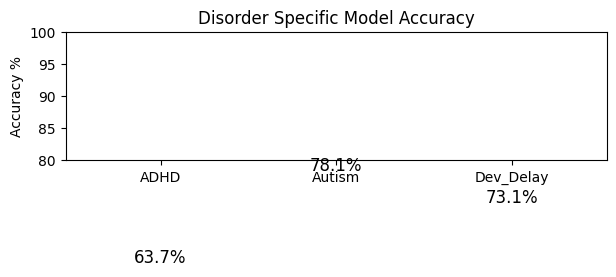

In [ ]:
#plot
import matplotlib.pyplot as plt
names = list(disorder_results.keys())
accs = [disorder_results[n]['accuracy']*100 for n in names]
bars = plt.bar(names, accs, color=['#3498db', '#e74c3c', '#2ecc71'])
for bar, val in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=12)
plt.title('Disorder Specific Model Accuracy')
plt.ylabel('Accuracy %')
plt.ylim(80, 100)
plt.tight_layout()
plt.show()

In [ ]:
###widgets
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np

patient_name = widgets.Text(
    value='',
    placeholder='Enter patient name',
    description='Patient Name:',
    style={'description_width': 'initial'})

k6q15 = widgets.IntSlider(min=0, max=1, value=0,
    description='Needs extra medical care (0=No, 1=Yes):',
    style={'description_width': 'initial'})

memorycond = widgets.IntSlider(min=0, max=1, value=0,
    description='Memory/concentration problems (0=No, 1=Yes):',
    style={'description_width': 'initial'})

k4q36 = widgets.IntSlider(min=0, max=1, value=0,
    description='Difficulty with daily activities (0=No, 1=Yes):',
    style={'description_width': 'initial'})

hcability = widgets.FloatSlider(min=0, max=1, step=0.1, value=0.5,
    description='Healthcare access (0=Poor, 1=Good):',
    style={'description_width': 'initial'})

sc_cshcn = widgets.IntSlider(min=0, max=1, value=0,
    description='Special healthcare needs (0=No, 1=Yes):',
    style={'description_width': 'initial'})

print("Widgets created successfully!")

Widgets created successfully!


In [ ]:
button = widgets.Button(description='Predict NDD Risk', button_style='primary')
output = widgets.Output()
def predict(b):
    with output:
        clear_output()
        name = patient_name.value if patient_name.value else "Unknown Patient"

        child_input = X_test_final.median().values.copy()
        feature_list = list(X_test_final.columns)

        for feat, val in [('k6q15', k6q15.value),
                          ('memorycond', memorycond.value),
                          ('k4q36', k4q36.value),
                          ('hcability', hcability.value),
                          ('sc_cshcn', sc_cshcn.value)]:
            if feat in feature_list:
                child_input[feature_list.index(feat)] = val

        prob = stacking_model.predict_proba([child_input])[0][1]

        if prob < 0.3:
            risk = 'LOW RISK'
            emoji = '🟢'
        elif prob < 0.6:
            risk = 'MEDIUM RISK'
            emoji = '🟡'
        else:
            risk = 'HIGH RISK'
            emoji = '🔴'

        print(f"\n{'='*40}")
        print(f"Patient: {name}")
        print(f"{'='*40}")
        print(f"{emoji} NDD Probability: {prob*100:.1f}%")
        print(f"{emoji} Risk Category: {risk}")
        print(f"\nTop factors driving this prediction:")

        child_df = pd.DataFrame([child_input], columns=feature_list)
        child_shap = shap.TreeExplainer(xgb_model).shap_values(child_df)
        impact = pd.Series(child_shap[0], index=feature_list)
        top3 = impact.abs().nlargest(3)
        for feat in top3.index:
            direction = "increases" if impact[feat] > 0 else "decreases"
            print(f"  - {feat} {direction} NDD risk (impact: {impact[feat]:.3f})")
        print(f"{'='*40}")

button.on_click(predict)
print("Predict function ready!")

Predict function ready!


In [ ]:
print("=== LET'S CHECK IF YOUR CHILD IS MENTALLY STABLE OR NOT!! ===\n")
display(patient_name, k6q15, memorycond, k4q36,
        hcability, sc_cshcn, button, output)

=== LET'S CHECK IF YOUR CHILD IS MENTALLY STABLE OR NOT!! ===



Text(value='', description='Patient Name:', placeholder='Enter patient name', style=DescriptionStyle(descripti…

IntSlider(value=0, description='Needs extra medical care (0=No, 1=Yes):', max=1, style=SliderStyle(description…

IntSlider(value=0, description='Memory/concentration problems (0=No, 1=Yes):', max=1, style=SliderStyle(descri…

IntSlider(value=0, description='Difficulty with daily activities (0=No, 1=Yes):', max=1, style=SliderStyle(des…

FloatSlider(value=0.5, description='Healthcare access (0=Poor, 1=Good):', max=1.0, style=SliderStyle(descripti…

IntSlider(value=0, description='Special healthcare needs (0=No, 1=Yes):', max=1, style=SliderStyle(description…

Button(button_style='primary', description='Predict NDD Risk', style=ButtonStyle())

Output()

In [ ]:
print("=== Clinical NDD Screening Questionnaire ===\n")

###patient info
sq_name = widgets.Text(
    placeholder='Enter patient name',
    description='Patient Name:',
    style={'description_width': 'initial'})

sq_age = widgets.IntSlider(min=1, max=17, value=5,
    description='Age of child (years):',
    style={'description_width': 'initial'})

sq_gender = widgets.Dropdown(
    options=[('Male', 'Male'), ('Female', 'Female')],
    description='Gender:',
    style={'description_width': 'initial'})

#clinical questions
q1 = widgets.Dropdown(
    options=[('Never', 0), ('Sometimes', 1), ('Often', 2), ('Always', 3)],
    description='1. Can not hold eye contact or avoids it.:',
    style={'description_width': 'initial'})

q2 = widgets.Dropdown(
    options=[('Never', 0), ('Sometimes', 1), ('Often', 2), ('Always', 3)],
    description='2. Highkey dyslexic:',
    style={'description_width': 'initial'})

q3 = widgets.Dropdown(
    options=[('Never', 0), ('Sometimes', 1), ('Often', 2), ('Always', 3)],
    description='3. Repetitive behaviors:',
    style={'description_width': 'initial'})

q4 = widgets.Dropdown(
    options=[('Never', 0), ('Sometimes', 1), ('Often', 2), ('Always', 3)],
    description='4. Struggles socially or no social skills.:',
    style={'description_width': 'initial'})

q5 = widgets.Dropdown(
    options=[('Never', 0), ('Sometimes', 1), ('Often', 2), ('Always', 3)],
    description='5. Emotional outbursts:',
    style={'description_width': 'initial'})

q6 = widgets.Dropdown(
    options=[('Never', 0), ('Sometimes', 1), ('Often', 2), ('Always', 3)],
    description='6. Delayed speech:',
    style={'description_width': 'initial'})

q7 = widgets.Dropdown(
    options=[('Never', 0), ('Sometimes', 1), ('Often', 2), ('Always', 3)],
    description='7. Sensitivity to sound/light:',
    style={'description_width': 'initial'})

q8 = widgets.Dropdown(
    options=[('Never', 0), ('Sometimes', 1), ('Often', 2), ('Always', 3)],
    description='8. Difficulty making friends:',
    style={'description_width': 'initial'})

q9 = widgets.Dropdown(
    options=[('Never', 0), ('Sometimes', 1), ('Often', 2), ('Always', 3)],
    description='9. Poor memory/concentration:',
    style={'description_width': 'initial'})

q10 = widgets.Dropdown(
    options=[('Never', 0), ('Sometimes', 1), ('Often', 2), ('Always', 3)],
    description='10. Difficulty with daily tasks:',
    style={'description_width': 'initial'})

sq_button = widgets.Button(
    description='Screen for NDD',
    button_style='primary')
sq_output = widgets.Output()

def screen(b):
    with sq_output:
        clear_output()

        name = sq_name.value if sq_name.value else "Unknown Patient"
        total_score = q1.value + q2.value + q3.value + q4.value + q5.value + \
                      q6.value + q7.value + q8.value + q9.value + q10.value
        max_score = 30
        percentage = (total_score / max_score) * 100
        autism_score = q1.value + q3.value + q4.value + q7.value + q8.value
        adhd_score = q2.value + q5.value + q9.value + q10.value
        dev_delay_score = q6.value + q2.value + q10.value

        ###risk level
        if percentage < 30:
            risk = 'LOW RISK'
            emoji = '🟢'
            advice = 'No immediate concern. Continue routine checkups.'
        elif percentage < 60:
            risk = 'MEDIUM RISK'
            emoji = '🟡'
            advice = 'Some indicators present. Recommend follow-up screening.'
        else:
            risk = 'HIGH RISK'
            emoji = '🔴'
            advice = 'Multiple indicators present. Recommend clinical evaluation.'

        ###ikely to suffer with disorder
        scores = {
            'ADHD': adhd_score,
            'Autism': autism_score,
            'Developmental Delay': dev_delay_score
        }
        likely = max(scores, key=scores.get)

        print(f"\n{'='*45}")
        print(f"  SCREENING REPORT")
        print(f"{'='*45}")
        print(f"  Patient    : {name}")
        print(f"  Age        : {sq_age.value} years")
        print(f"  Gender     : {sq_gender.value}")
        print(f"{'='*45}")
        print(f"  Total Score: {total_score}/{max_score} ({percentage:.0f}%)")
        print(f"  {emoji} Risk Level : {risk}")
        print(f"{'='*45}")
        print(f"\n  Disorder Indicator Scores:")
        print(f"  ADHD               : {adhd_score}/12")
        print(f"  Autism             : {autism_score}/15")
        print(f"  Developmental Delay: {dev_delay_score}/9")
        print(f"\n  Most likely concern: {likely}")
        print(f"\n  Recommendation:")
        print(f"  {advice}")
        print(f"{'='*45}")

sq_button.on_click(screen)

display(sq_name, sq_age, sq_gender,
        widgets.HTML('<hr><b>Rate each behavior:</b><br>'),
        q1, q2, q3, q4, q5,
        q6, q7, q8, q9, q10,
        sq_button, sq_output)

=== Clinical NDD Screening Questionnaire ===



Text(value='', description='Patient Name:', placeholder='Enter patient name', style=DescriptionStyle(descripti…

IntSlider(value=5, description='Age of child (years):', max=17, min=1, style=SliderStyle(description_width='in…

Dropdown(description='Gender:', options=(('Male', 'Male'), ('Female', 'Female')), style=DescriptionStyle(descr…

HTML(value='<hr><b>Rate each behavior:</b><br>')

...

Dropdown(description='8. Difficulty making friends:', options=(('Never', 0), ('Sometimes', 1), ('Often', 2), (…

Dropdown(description='9. Poor memory/concentration:', options=(('Never', 0), ('Sometimes', 1), ('Often', 2), (…

Dropdown(description='10. Difficulty with daily tasks:', options=(('Never', 0), ('Sometimes', 1), ('Often', 2)…

Button(button_style='primary', description='Screen for NDD', style=ButtonStyle())

Output()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
###probability scores from stacking model
y_proba = stacking_model.predict_proba(X_test_final)[:, 1]

In [ ]:
def categorize_risk(prob):
    if prob < 0.3:
        return 'Low Risk'
    elif prob < 0.6:
        return 'Medium Risk'
    else:
        return 'High Risk'
risk_categories = [categorize_risk(p) for p in y_proba]
risk_df = pd.DataFrame({
    'NDD_probability': y_proba,
    'Risk_Category': risk_categories,
    'Actual_Label': y_test.values
})

In [ ]:
print("Risk Category Distribution:")
print(risk_df['Risk_Category'].value_counts())
print("\nRisk vs Actual NDD:")
print(pd.crosstab(risk_df['Risk_Category'], risk_df['Actual_Label'],
                  rownames=['Risk Category'],
                  colnames=['Actual NDD']))

Risk Category Distribution:
Risk_Category
Low Risk       7539
High Risk      2153
Medium Risk     583
Name: count, dtype: int64

Risk vs Actual NDD:
Actual NDD        0     1
Risk Category            
High Risk       414  1739
Low Risk       7149   390
Medium Risk     357   226


Child index: 16
Actual NDD: Yes
Predicted NDD probability: 98.3%
Risk Category: High Risk

Top 5 features driving this prediction:
  k6q15: 1.594 (towards NDD)
  memorycond: 0.960 (towards NDD)
  k4q36: 0.900 (towards NDD)
  k7q85_r: 0.618 (towards NDD)
  k2q34a: 0.600 (towards NDD)


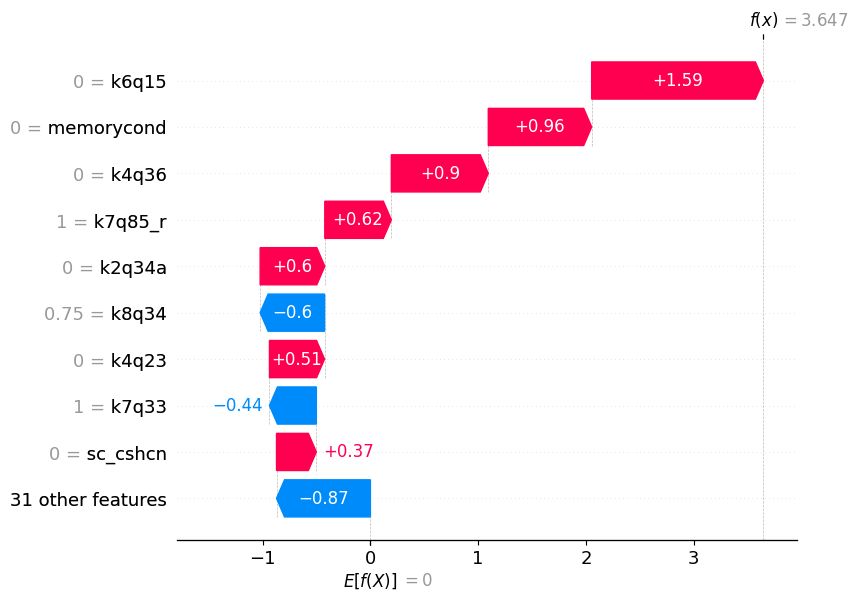

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
###high risk child who actually has NDD
high_risk_ndd = risk_df[(risk_df['Risk_Category'] == 'High Risk') &
                         (risk_df['Actual_Label'] == 1)].index[0]

child = X_test_final.iloc[high_risk_ndd:high_risk_ndd+1]
prob = risk_df.loc[high_risk_ndd, 'NDD_probability']
actual = risk_df.loc[high_risk_ndd, 'Actual_Label']

print(f"Child index: {high_risk_ndd}")
print(f"Actual NDD: {'Yes' if actual == 1 else 'No'}")
print(f"Predicted NDD probability: {prob*100:.1f}%")
print(f"Risk Category: {risk_df.loc[high_risk_ndd, 'Risk_Category']}")
print("\nTop 5 features driving this prediction:")

child_shap = shap.TreeExplainer(xgb_model).shap_values(child)
feature_impact = pd.Series(child_shap[0], index=top_40_cols)
top5 = feature_impact.abs().nlargest(5)
for feat in top5.index:
    direction = "towards NDD" if feature_impact[feat] > 0 else "away from NDD"
    print(f"  {feat}: {feature_impact[feat]:.3f} ({direction})")

###waterfall plot
shap.plots.waterfall(shap.Explanation(
    values=child_shap[0],
    base_values=shap.TreeExplainer(xgb_model).expected_value,
    data=child.values[0],
    feature_names=top_40_cols
))

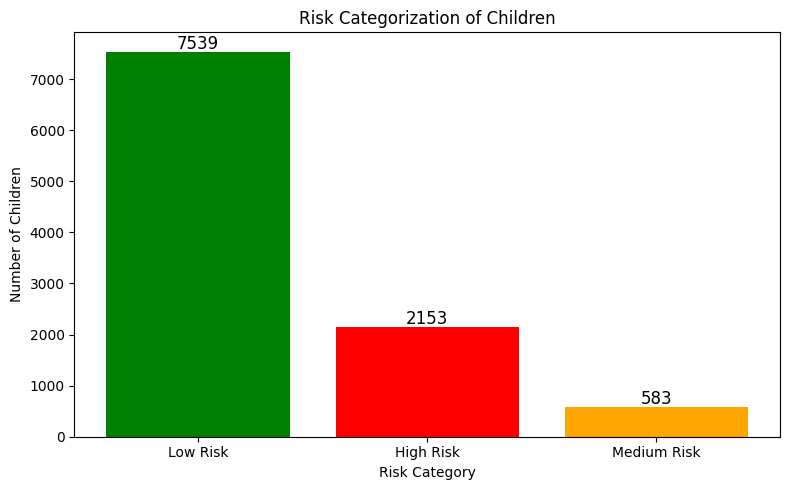

In [ ]:
#plot
colors = {'Low Risk': 'green', 'Medium Risk': 'orange', 'High Risk': 'red'}
risk_counts = risk_df['Risk_Category'].value_counts()
plt.figure(figsize=(8, 5))
bars = plt.bar(risk_counts.index,
               risk_counts.values,
               color=[colors[r] for r in risk_counts.index])
plt.title('Risk Categorization of Children')
plt.xlabel('Risk Category')
plt.ylabel('Number of Children')
for bar, val in zip(bars, risk_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             str(val), ha='center', fontsize=12)
plt.tight_layout()
plt.show()